# Consigna para el 20/04/27: Armar el modelo en base de las VR Y VD
### **VR:** Son indicadores de desempeño(OUTPUTS)--> lo que queremos medir para ver si el sistema va bien o mal-->
Ejemplo: el tiempo, la produccion. Constantemente se evaluan para ver diferentes escenarios.

### **VD:** Parametros que pueden controlarse o modificarse(INPUTS) para ver si puedo mejorar el sistema. Se toman las desiciones aca y luego se ven los efectos en las VR.
Ejemplo: cantidad de maquinas, reposicion.

### **VR** dice: ¿Como le esta yendo a mi sistema?
### **VD** dice: ¿Que cambios puedo hacer?

# Caso de Simulación elegido: Terminal Baires.

## Descripción del problema:

TERMINAL BAIRES opera un puerto de carga y descarga de contenedores en La Plata.

El puerto tiene un muelle para el amarre de barcos portacontenedores de mediano porte y
opera con una sola grúa.

La operación normalmente sigue el siguiente trámite: Cuando un barco llega a puerto espera en el antepuerto hasta que tenga “muelle libre”.  En general en este momento el
barco informa al administrador del puerto el número y ubicación de los contenedores a cargar o descargar. Una vez que se le autoriza el acceso el barco recibe el práctico a bordo
y realiza las tareas de amarre. Concluido el amarre comienza la operación de descarga de
contenedores primero y carga después. Una vez terminada la operación, el barco parte,
nuevamente con la asistencia del práctico.

El puerto opera las 24 horas, todos los días de
la semana y cuenta con un servicio permanente de prácticos.
Actualmente el puerto recibe en promedio 10 barcos/mes. Los barcos operan con
contenedores y medio-contenedores, en general el 80% corresponde a contenedores
completos. La operación de contenedores para cada barco oscila entre 5-10 contenedores
en la descarga y 10-15 contenedores en la carga. Cuando las condiciones climáticas no
son seguras el puerto no opera.

En los últimos meses se ha verificado un aumento en las paradas de la grúa por
inconvenientes mecánicos que han llegado al 15% del tiempo total operativo. También se
ha apreciado un aumento en la proporción de carga de medio-contenedores.

El administrador del puerto desea establecer si es necesario incorporar una nueva grúa de
forma tal de poder operar cada barco con las dos grúas. También desea ver si debe
considerar un cargo adicional por la operación de medio-contenedores.

La gerencia técnica del administrador del puerto puede suministrar los datos adicionales
que disponga para realizar el estudio.

# Entender el problema: La entidad principal es el barco, todo el flujo de trabajo gira alrededor de la llegada, espera, operación y partida.

In [ ]:
#LLEGADA AL ANTEPUERTO
        #↓
#¿Muelle libre?  →  NO → ESPERA EN ANTEPUERTO (cola)
        #↓ SI
#Informa contenedores al administrador
        #↓
#Recibe PRÁCTICO a bordo
        #↓
#AMARRE al muelle
        #↓
#DESCARGA (5-10 contenedores)
        #↓
#CARGA (10-15 contenedores)
        #↓
#Recibe PRÁCTICO para partir
        #↓
#PARTIDA

Codigo de VR y VD

In [ ]:
!pip install graphviz

In [ ]:
"""
SIMULACIÓN — TERMINAL BAIRES
Diagrama VR/VD + Matriz de impacto combinados
Dependencia: pip install matplotlib
"""

import matplotlib
#matplotlib.use("Agg")   # Eliminar en Jupyter
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor("white")

# ── Paleta ────────────────────────────────────
C_GRAY_FILL = "#D3D1C7"; C_GRAY_TXT  = "#2C2C2A"
C_VD_HDR    = "#F0997B"; C_VD_FILL   = "#F5C4B3"
C_VD_EDGE   = "#D85A30"; C_VD_TXT    = "#4A1B0C"
C_VR_HDR    = "#5DCAA5"; C_VR_LIGHT  = "#9FE1CB"
C_VR_MID    = "#5DCAA5"; C_VR_DARK   = "#1D9E75"
C_VR_EDGE   = "#0F6E56"; C_VR_TXT    = "#04342C"; C_VR_DTXT = "#E1F5EE"

VD_COLORS = ["#C0392B", "#1A6B8A", "#6B4C9A"]
VD_NAMES  = ["VD1", "VD2", "VD3"]

def box(ax, x, y, w, h, label, sublabel=None,
        fc="#fff", ec="#999", tc="#000", tc2="#555", r=0.15, fs=9.5, fs2=8):
    p = FancyBboxPatch((x - w/2, y - h/2), w, h,
                        boxstyle=f"round,pad=0.02,rounding_size={r}",
                        fc=fc, ec=ec, lw=1.3, zorder=3)
    ax.add_patch(p)
    if sublabel:
        ax.text(x, y + 0.14, label,    ha="center", va="center",
                fontsize=fs,  fontweight="bold", color=tc,  zorder=4)
        ax.text(x, y - 0.19, sublabel, ha="center", va="center",
                fontsize=fs2, color=tc2, zorder=4)
    else:
        ax.text(x, y, label, ha="center", va="center",
                fontsize=fs, fontweight="bold", color=tc, zorder=4)

def arrow(ax, x1, y1, x2, y2, color="#888", lw=1.1, ls="--", rad=0.0):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                linestyle=ls,
                                connectionstyle=f"arc3,rad={rad}"),
                zorder=2)

# ══════════════════════════════════════════════
# PARTE 1 — Diagrama de flechas
# ══════════════════════════════════════════════
ax1 = fig.add_axes([0.0, 0.42, 1.0, 0.56])
ax1.set_xlim(0, 22); ax1.set_ylim(0, 13); ax1.axis("off")

X_SYS = 2.2; X_VD = 7.2; X_VR = 16.5
BW_SYS = 3.4; BH_SYS = 1.0
BW_HDR = 4.4; BH_HDR = 0.80
BW_VD  = 4.4; BH_VD  = 0.80
BW_VR  = 4.8; BH_VR  = 0.80

Y_SYS    = 6.5
Y_VD_HDR = 11.5; Y_VR_HDR = 11.5
Y_VDs    = [9.2, 6.5, 3.8]
Y_VRs    = [9.8, 8.5, 7.2, 5.9, 4.6, 3.3]

box(ax1, X_SYS, Y_SYS, BW_SYS, BH_SYS,
    "TERMINAL BAIRES", "Puerto de contenedores, La Plata",
    fc=C_GRAY_FILL, ec="#888780", tc=C_GRAY_TXT, tc2="#5F5E5A")

box(ax1, X_VD, Y_VD_HDR, BW_HDR, BH_HDR,
    "VARIABLES DE DECISIÓN", "¿Qué puede cambiar el administrador?",
    fc=C_VD_HDR, ec=C_VD_EDGE, tc=C_VD_TXT, tc2=C_VD_TXT)
box(ax1, X_VR, Y_VR_HDR, BW_HDR, BH_HDR,
    "VARIABLES DE REFERENCIA", "¿Cómo medir el desempeño?",
    fc=C_VR_HDR, ec=C_VR_EDGE, tc=C_VR_TXT, tc2=C_VR_TXT)

vd_data = [
    ("VD1 — Cantidad de grúas",     "1 grúa actual  vs.  2 grúas simultáneas"),
    ("VD2 — Tarifa diferencial",    "Cargo extra por medio-contenedor"),
    ("VD3 — Mantenimiento de grúa", "Reducir fallas del 15% con prev."),
]
for i, ((lbl, sub), y) in enumerate(zip(vd_data, Y_VDs)):
    box(ax1, X_VD, y, BW_VD, BH_VD, lbl, sub,
        fc=C_VD_FILL, ec=VD_COLORS[i], tc=C_VD_TXT, tc2="#7B3010")
    dot = FancyBboxPatch((X_VD - BW_VD/2 + 0.08, y - 0.14), 0.28, 0.28,
                          boxstyle="round,pad=0.02,rounding_size=0.08",
                          fc=VD_COLORS[i], ec="none", zorder=5)
    ax1.add_patch(dot)
    ax1.text(X_VD - BW_VD/2 + 0.22, y, str(i+1),
             ha="center", va="center", fontsize=7, fontweight="bold",
             color="white", zorder=6)

vr_data = [
    ("VR1 — Espera en antepuerto",    "Tiempo hasta acceso al muelle",   C_VR_LIGHT, C_VR_TXT),
    ("VR2 — Estadía total del barco", "Desde llegada hasta partida",     C_VR_LIGHT, C_VR_TXT),
    ("VR3 — Utilización de la grúa",  "% tiempo operativa vs. total",    C_VR_MID,   C_VR_TXT),
    ("VR4 — Throughput del puerto",   "Barcos y contenedores por mes",   C_VR_MID,   C_VR_TXT),
    ("VR5 — Barcos en cola",          "Promedio y máximo en antepuerto", C_VR_MID,   C_VR_TXT),
    ("VR6 — Tiempo perdido/fallas",   "Impacto del 15% de paradas",      C_VR_DARK,  C_VR_DTXT),
]
for (lbl, sub, fc, tc), y in zip(vr_data, Y_VRs):
    box(ax1, X_VR, y, BW_VR, BH_VR, lbl, sub,
        fc=fc, ec=C_VR_EDGE, tc=tc, tc2=tc)

arrow(ax1, X_SYS+BW_SYS/2, Y_SYS+0.25, X_VD-BW_HDR/2, Y_VD_HDR,
      color=C_VD_EDGE, lw=1.6, ls="-")
arrow(ax1, X_SYS+BW_SYS/2, Y_SYS-0.25, X_VR-BW_VR/2, Y_VR_HDR,
      color=C_VR_EDGE, lw=1.6, ls="-")
for y in Y_VDs:
    arrow(ax1, X_SYS+BW_SYS/2, Y_SYS, X_VD-BW_VD/2, y,
          color=C_VD_EDGE, lw=1.0, ls="-")

rels = [
    (0, 0, 0.0), (0, 1, 0.04), (0, 2,-0.04),
    (0, 3, 0.06), (0, 4, 0.09),
    (1, 5, 0.0),
    (2, 0,-0.09), (2, 2, 0.0), (2, 5, 0.06),
]
for vd_i, vr_i, rad in rels:
    arrow(ax1, X_VD+BW_VD/2, Y_VDs[vd_i],
              X_VR-BW_VR/2, Y_VRs[vr_i],
          color=VD_COLORS[vd_i], lw=1.2, ls="--", rad=rad)

# Leyenda flechas
lx = 10.5; ly = 1.2
ax1.text(lx, ly+0.5, "Color de flechas:", fontsize=8,
         color="#2C2C2A", fontweight="bold", va="center")
for i, (col, (lbl, _)) in enumerate(zip(VD_COLORS, vd_data)):
    xi = lx + i * 3.6
    ax1.annotate("", xy=(xi+0.7, ly), xytext=(xi, ly),
                arrowprops=dict(arrowstyle="-|>", color=col, lw=1.5, linestyle="--"))
    ax1.text(xi+0.8, ly, lbl.split("—")[1].strip(),
             fontsize=7.5, color=col, va="center", fontweight="bold")

for i, (fc, ec, lbl) in enumerate([
    (C_VD_FILL, C_VD_EDGE, "Variable de Decisión (VD)"),
    (C_VR_MID,  C_VR_EDGE, "Variable de Referencia (VR)"),
]):
    lx2, ly2 = 0.3, 0.85 - i*0.38
    ax1.add_patch(FancyBboxPatch((lx2, ly2), 0.38, 0.24,
                  boxstyle="round,pad=0.02,rounding_size=0.06",
                  fc=fc, ec=ec, lw=1.0))
    ax1.text(lx2+0.50, ly2+0.12, lbl, fontsize=8, va="center", color="#2C2C2A")

ax1.axhline(1.05, xmin=0.01, xmax=0.99, color="#D3D1C7", lw=0.8)
ax1.text(11, 12.6, "TERMINAL BAIRES — Variables de Referencia y Decisión",
         ha="center", va="center", fontsize=15, fontweight="bold", color="#2C2C2A")

# ══════════════════════════════════════════════
# PARTE 2 — Matriz de impacto
# ══════════════════════════════════════════════
ax2 = fig.add_axes([0.05, 0.01, 0.90, 0.38])
ax2.set_xlim(0, 18); ax2.set_ylim(0, 8); ax2.axis("off")

ax2.text(9, 7.5, "Matriz de impacto — VD → VR",
         ha="center", va="center", fontsize=13, fontweight="bold", color="#2C2C2A")
ax2.text(9, 7.0,
         "Cada celda indica qué efecto produce una Variable de Decisión sobre una Variable de Referencia",
         ha="center", va="center", fontsize=8.5, color="#5F5E5A")

vd_labels = ["VD1\nCantidad de grúas", "VD2\nTarifa diferencial", "VD3\nMantenimiento\nde grúa"]
vr_labels = ["VR1\nEspera\nantepuerto","VR2\nEstadía\ntotal","VR3\nUtilización\ngrúa",
             "VR4\nThroughput\npuerto","VR5\nBarcos\nen cola","VR6\nTiempo\nperdido"]

NONE = ("—", "#F1EFE8", "#B4B2A9")
impacts = [
    [("↓ reduce","#FAEEDA","#633806"),("↓ reduce","#FAEEDA","#633806"),("↑ aumenta","#EAF3DE","#173404"),("↑ aumenta","#EAF3DE","#173404"),("↓ reduce","#FAEEDA","#633806"),NONE],
    [NONE, NONE, NONE, NONE, NONE, ("$ justifica","#E6F1FB","#042C53")],
    [("↓ reduce","#FAEEDA","#633806"),NONE,("↑ mejora","#EAF3DE","#173404"),NONE,NONE,("↓ reduce","#FAEEDA","#633806")],
]

col_w = 2.3; row_h = 1.5
x0 = 2.8; y0 = 5.8; header_h = 0.9; header_w = 2.2

for j, lbl in enumerate(vr_labels):
    xc = x0 + j*col_w + col_w/2
    ax2.add_patch(FancyBboxPatch((x0+j*col_w+0.06, y0-header_h+0.06),
                  col_w-0.12, header_h-0.08,
                  boxstyle="round,pad=0.02,rounding_size=0.08",
                  fc=C_VR_MID, ec=C_VR_EDGE, lw=1.0, zorder=3))
    ax2.text(xc, y0-header_h/2+0.03, lbl, ha="center", va="center",
             fontsize=7.5, fontweight="bold", color=C_VR_TXT, zorder=4)

for i, (vd_lbl, row) in enumerate(zip(vd_labels, impacts)):
    yc = y0 - header_h - i*row_h - row_h/2
    ax2.add_patch(FancyBboxPatch((0.06, yc-row_h/2+0.06), header_w-0.12, row_h-0.10,
                  boxstyle="round,pad=0.02,rounding_size=0.08",
                  fc=C_VD_FILL, ec=VD_COLORS[i], lw=1.3, zorder=3))
    ax2.text(header_w/2, yc, vd_lbl, ha="center", va="center",
             fontsize=8, fontweight="bold", color=C_VD_TXT, zorder=4)
    ax2.add_patch(FancyBboxPatch((0.10, yc+row_h/2-0.35), 0.22, 0.22,
                  boxstyle="round,pad=0.01,rounding_size=0.06",
                  fc=VD_COLORS[i], ec="none", zorder=5))
    for j, (txt, fc, tc) in enumerate(row):
        xc = x0 + j*col_w + col_w/2
        ax2.add_patch(FancyBboxPatch((x0+j*col_w+0.06, yc-row_h/2+0.06),
                      col_w-0.12, row_h-0.10,
                      boxstyle="round,pad=0.02,rounding_size=0.08",
                      fc=fc, ec="#D3D1C7", lw=0.8, zorder=3))
        ax2.text(xc, yc, txt, ha="center", va="center",
                 fontsize=9, fontweight="bold", color=tc, zorder=4)

fig.add_artist(plt.Line2D([0.03, 0.97], [0.405, 0.405],
               transform=fig.transFigure,
               color="#D3D1C7", lw=1.2, linestyle="--"))

plt.savefig("terminal_baires_completo.png", dpi=180,
            bbox_inches="tight", facecolor="white")
print("Guardado: terminal_baires_completo.png")

# ── Jupyter: descomentar ──────────────────────
# from IPython.display import Image
# Image("terminal_baires_completo.png")

Guardado: terminal_baires_completo.png


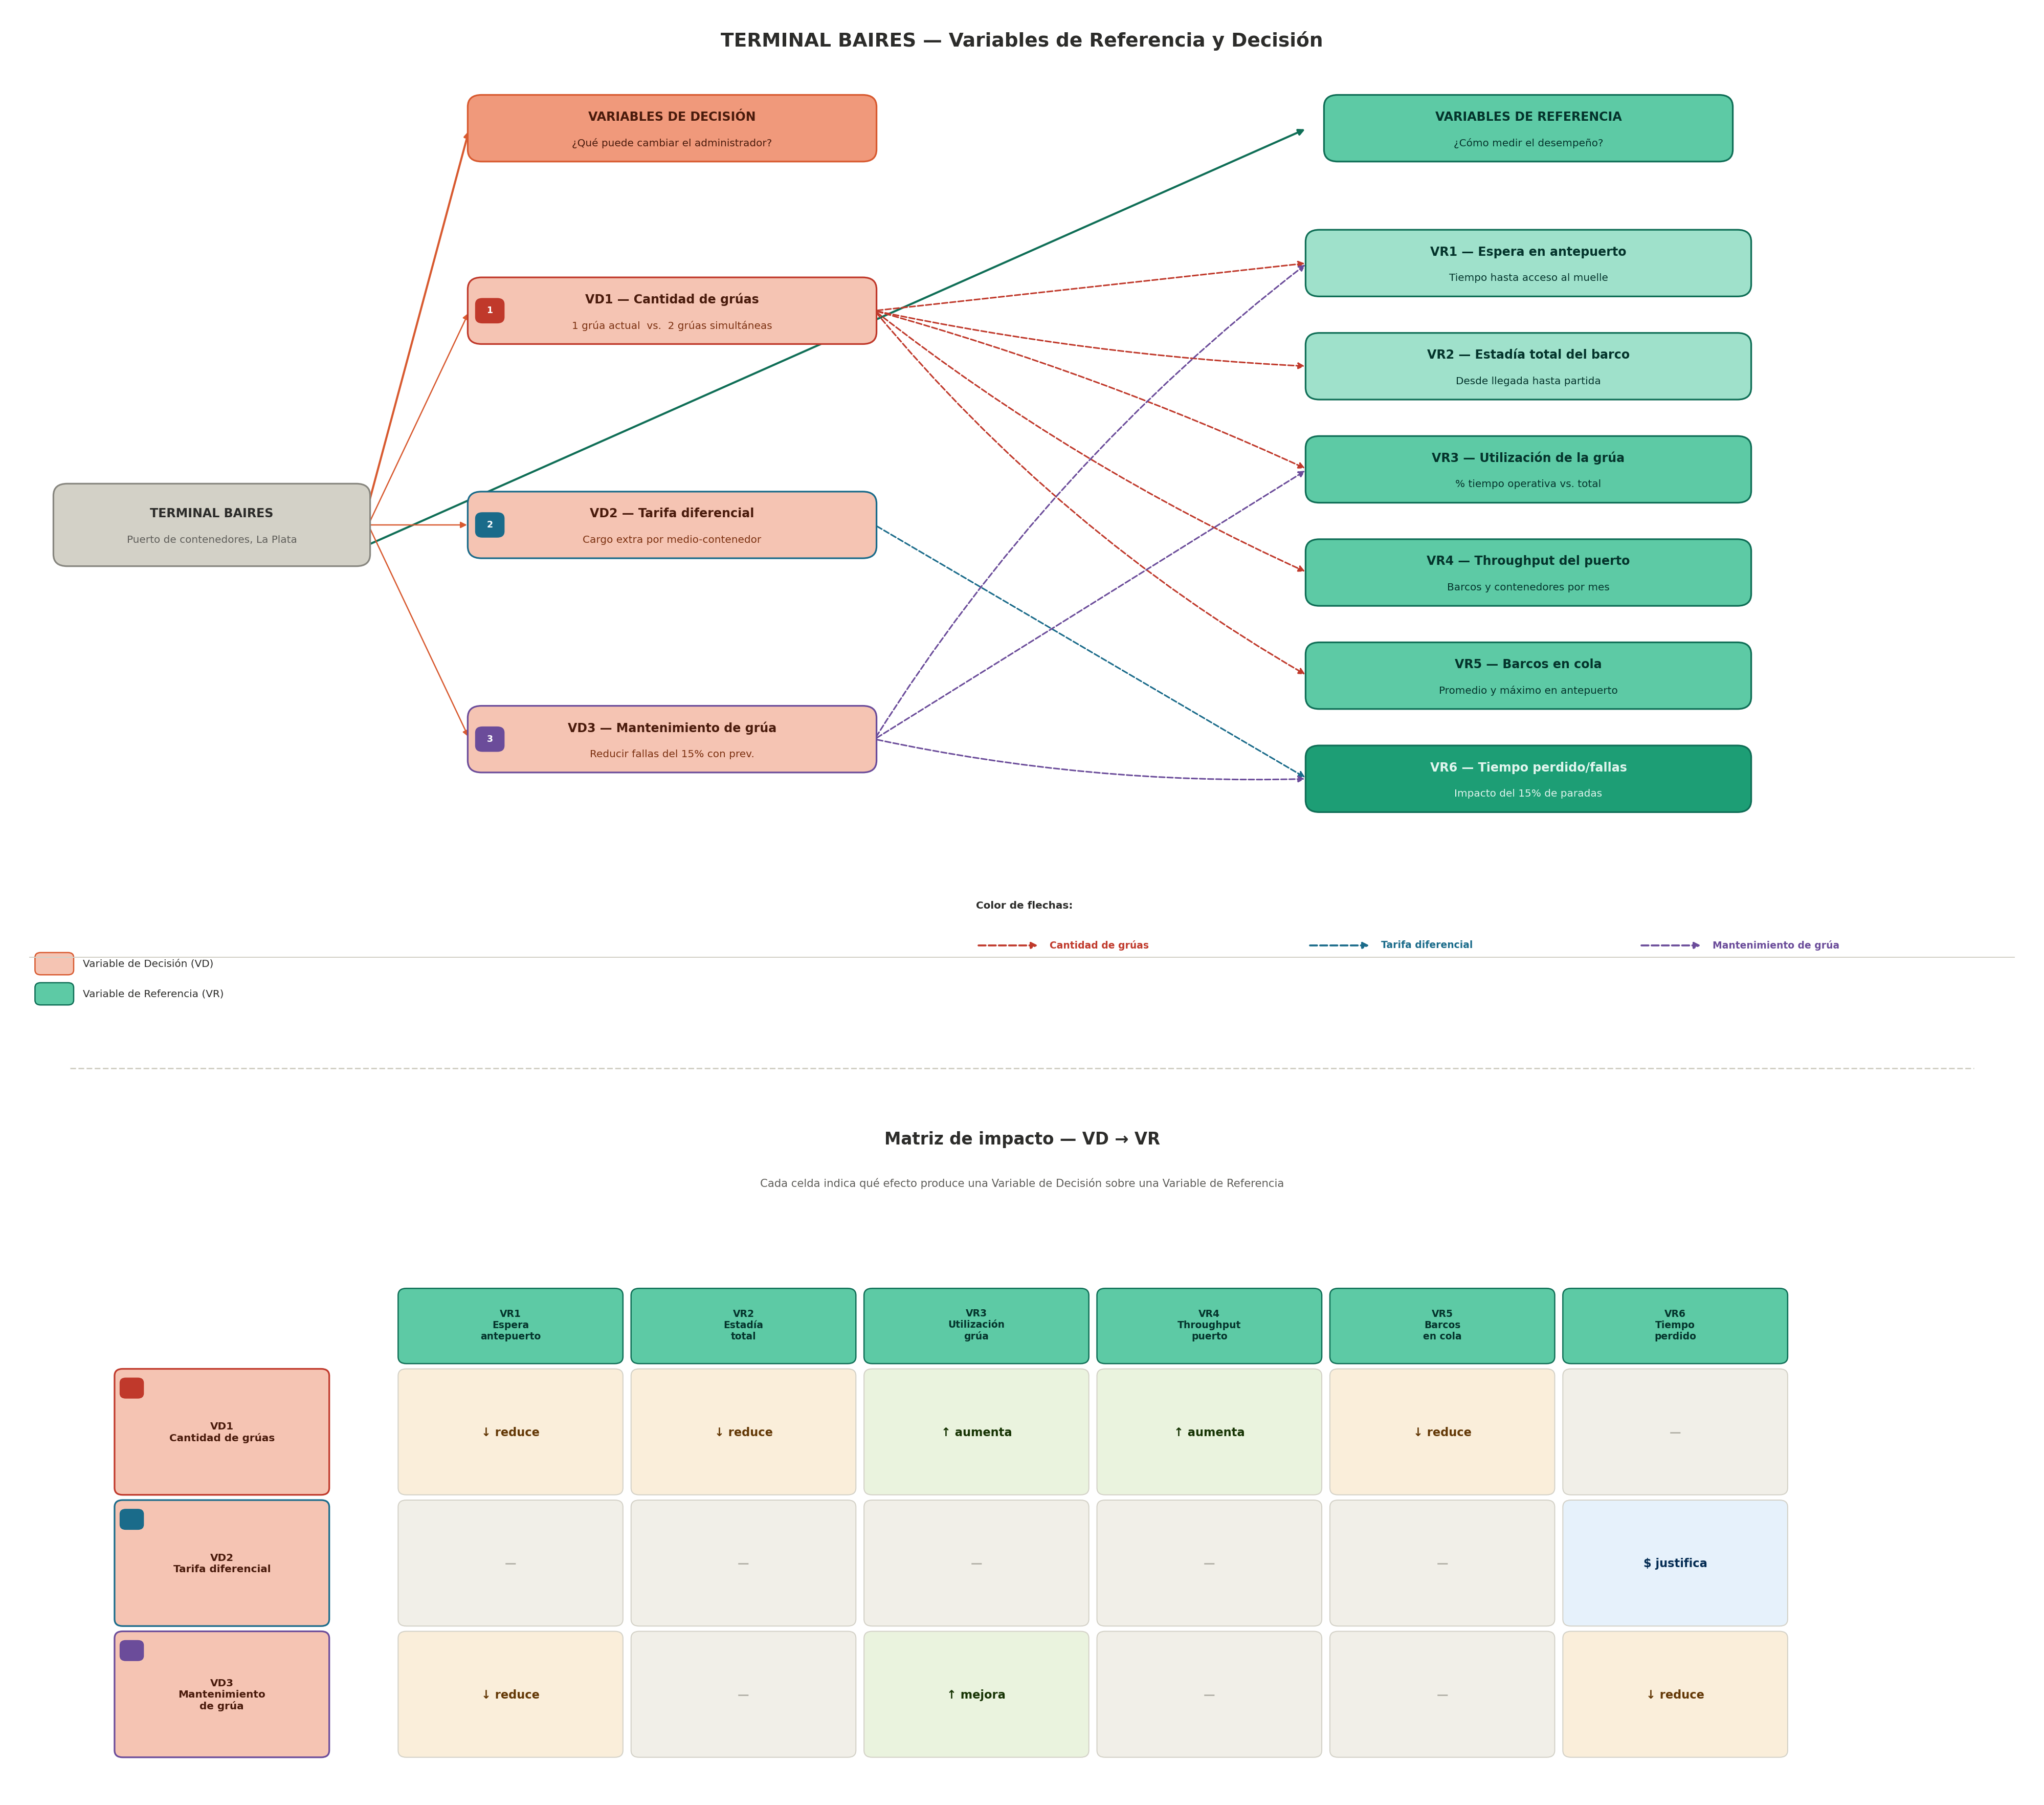

In [ ]:
from IPython.display import Image
Image("terminal_baires_completo.png")

# TERMINAL BAIRES — Variables de Referencia y Decisión

## ¿Qué muestra el diagrama?

El diagrama representa la arquitectura de análisis del sistema **Terminal Baires**, un puerto de carga y descarga de contenedores en La Plata. Está organizado en tres columnas: el sistema como punto de origen, las Variables de Decisión (VD) que el administrador puede controlar, y las Variables de Referencia (VR) que miden el desempeño del sistema. La matriz de impacto inferior precisa qué efecto produce cada VD sobre cada VR.

---

## Variables de Decisión (VD)

Son los **parámetros que el administrador del puerto puede modificar**. Representan las "palancas" del sistema: las decisiones concretas que se pueden tomar y cuyos efectos se quieren evaluar mediante la simulación.

### 🔴 VD1 — Cantidad de grúas
**Escenarios:** 1 grúa (situación actual) vs. 2 grúas operando simultáneamente por barco.

Esta es la variable de decisión más importante del caso. Actualmente el puerto opera con una sola grúa, que además registra un 15% de tiempo fuera de servicio por fallas mecánicas. La pregunta central es si incorporar una segunda grúa reduciría los tiempos de operación lo suficiente como para justificar la inversión. Al operar con dos grúas en simultáneo, la descarga y carga de cada barco se realiza en paralelo, lo que impacta directamente en casi todos los indicadores del sistema.

### 🔵 VD2 — Tarifa diferencial por medio-contenedor
**Escenarios:** sin cargo adicional (situación actual) vs. cargo extra por operación de medio-contenedor.

Los medio-contenedores representan actualmente el 20% de las operaciones y su proporción está creciendo. Operarlos requiere más tiempo que un contenedor completo porque ocupan diferente espacio en la grúa y demandan una manipulación distinta. Esta variable no modifica la operación física del puerto, pero permite cuantificar el sobrecosto operativo que generan y evaluar si corresponde trasladarlo al cliente como un cargo diferencial.

### 🟣 VD3 — Política de mantenimiento de la grúa
**Escenarios:** mantenimiento correctivo actual (se repara cuando falla) vs. mantenimiento preventivo que reduzca la tasa de fallas del 15% actual.

Las paradas mecánicas de la grúa llegaron al 15% del tiempo total operativo, lo cual es muy alto. Cada vez que la grúa falla, el barco queda inmovilizado en el muelle esperando la reparación, bloqueando el acceso a otros barcos que están en cola en el antepuerto. Implementar un plan de mantenimiento preventivo implica un costo, pero la hipótesis es que reduciría las fallas y mejoraría la disponibilidad efectiva de la grúa.

---

## Variables de Referencia (VR)

Son los **indicadores de desempeño** del sistema. Se usan para medir cómo funciona el puerto bajo cada escenario simulado y para comparar alternativas. Son las salidas del modelo de simulación.

### VR1 — Tiempo de espera en el antepuerto
Mide cuánto tiempo transcurre desde que un barco llega al puerto hasta que recibe autorización para ingresar al muelle. Es el indicador de congestión más directo: si hay un barco en el muelle y otro llega, ese segundo barco espera en el antepuerto. Tiempos de espera altos implican costos para los armadores y pueden generar penalidades contractuales para el puerto.

### VR2 — Tiempo total de estadía del barco
Mide el tiempo completo desde la llegada del barco hasta su partida definitiva, incluyendo la espera en el antepuerto, el amarre, la descarga, la carga y el desamarre. Es el indicador global de eficiencia desde la perspectiva del cliente. Un barco que pasa menos tiempo total en el puerto tiene mayor disponibilidad para otros viajes.

### VR3 — Utilización de la grúa
Mide el porcentaje del tiempo en que la grúa está efectivamente operando sobre un barco, respecto al tiempo total disponible. Una utilización muy baja indica capacidad ociosa. Una utilización cercana al 100% indica un recurso saturado y sin margen ante imprevistos. El valor óptimo depende del sistema, pero el 15% de tiempo perdido por fallas reduce artificialmente este indicador.

### VR4 — Throughput del puerto
Mide la cantidad de barcos atendidos por mes y la cantidad de contenedores movidos por mes. Es el indicador de productividad global del sistema. Refleja cuánto trabajo efectivo realiza el puerto en un período determinado y es clave para evaluar si la capacidad instalada es suficiente para la demanda actual y futura.

### VR5 — Barcos en cola en el antepuerto
Mide el número promedio y el número máximo de barcos esperando en el antepuerto en un momento dado. Está directamente relacionado con VR1: si la espera aumenta, la cola crece. Sin embargo, aporta información adicional sobre los picos de congestión, que pueden ser más relevantes que el promedio para tomar decisiones de capacidad.

### VR6 — Tiempo perdido por fallas de la grúa
Mide el tiempo total acumulado en que la grúa estuvo fuera de servicio por inconvenientes mecánicos, y su impacto en la operación. Es la base cuantitativa para evaluar tanto la VD3 (¿cuánto mejoraría el sistema si se redujeran las fallas?) como la VD2 (¿cuánto del tiempo perdido se explica por la operación de medio-contenedores?).

---

## Matriz de impacto — cómo cada VD afecta a cada VR

| | VR1 Espera | VR2 Estadía | VR3 Utilización | VR4 Throughput | VR5 Cola | VR6 T. perdido |
|---|---|---|---|---|---|---|
| **VD1 — Grúas** | ↓ reduce | ↓ reduce | ↑ aumenta | ↑ aumenta | ↓ reduce | — |
| **VD2 — Tarifa** | — | — | — | — | — | $ justifica |
| **VD3 — Mantenimiento** | ↓ reduce | — | ↑ mejora | — | — | ↓ reduce |

### Lectura de la matriz

**VD1 impacta 5 de 6 indicadores.** Agregar una segunda grúa reduce la espera en antepuerto, la estadía total y la cola porque cada barco se despacha más rápido y libera el muelle antes. Al mismo tiempo aumenta la utilización del recurso grúa (se usa más) y el throughput (se atienden más barcos o contenedores en el mismo período). No tiene impacto directo sobre el tiempo perdido por fallas porque eso depende del estado mecánico, no de la cantidad de grúas.

**VD2 impacta solo 1 indicador.** La tarifa diferencial no cambia ningún tiempo operativo: los barcos siguen llegando igual, la grúa opera igual, las colas son las mismas. Su único efecto es sobre VR6: al cuantificar el tiempo extra que demanda operar medio-contenedores, justifica o no aplicar un cargo adicional. Es una decisión de pricing, no de operaciones.

**VD3 impacta 3 indicadores.** Reducir las fallas mecánicas tiene un efecto en cadena: menos fallas significa que la grúa está disponible más tiempo (↑ VR3), los barcos no quedan varados esperando reparaciones (↓ VR1) y el tiempo total perdido por paradas disminuye (↓ VR6). No impacta directamente sobre la estadía total, el throughput ni la cola porque esos indicadores dependen más de la capacidad de la grúa que de su disponibilidad.